# **Práctica de Laboratorio Nro. 015: (Evaluación Avanzada de Modelos): Construcción de curvas ROC, cálculo del Área Bajo la Curva (métrica AUC) y validación cruzada mediante técnicas de K-Fold.**

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes - Grupo B**
###Ariana Quezada
###Eduardo Soto
###Roy Gordillo
###Pablo Pineda
###Danny Beltran

###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 21 de julio de 2026

---

## **Tarea 1: La Curva ROC y el Área Bajo la Curva (AUC)**



En esta tarea evaluamos un clasificador binario a través de múltiples umbrales de decisión.
Calculamos la Tasa de Verdaderos Positivos (TPR) y la Tasa de Falsos Positivos (FPR) definidas por:

$$TPR = \frac{TP}{TP + FN} \quad ; \quad FPR = \frac{FP}{FP + TN}$$

Graficaremos la Curva ROC (Receiver Operating Characteristic) y calcularemos la métrica AUC (Area Under Curve) usando `scikit-learn`.

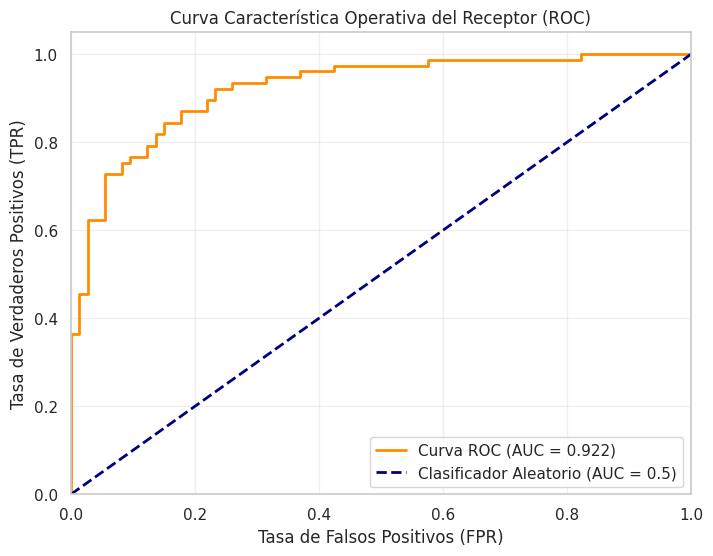


--- Reporte de Clasificación (Threshold = 0.5) ---
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        73
           1       0.87      0.77      0.81        77

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.83      0.82      0.82       150



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Simulación rápida de los datos
np.random.seed(42)
temp_cpu = np.random.uniform(40, 90, 500).reshape(-1, 1) # X
z = -10 + 0.15 * temp_cpu.ravel()
prob_falla = 1 / (1 + np.exp(-z))
y_real = np.random.binomial(1, p=prob_falla) # Etiquetas (0 o 1)

# División en Entrenamiento y Prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(temp_cpu, y_real, test_size=0.30, random_state=42)

# 2. Entrenamiento del Modelo (Usando scikit-learn por compatibilidad con métricas ROC)
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Obtener las PROBABILIDADES estimadas para el conjunto de prueba (columna 1)
y_prob_test = modelo.predict_proba(X_test)[:, 1]

# 3. Cálculo de la Curva ROC y AUC
fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

# 4. Visualización
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Reporte detallado de clasificación con umbral por defecto (0.5)
y_pred_test = modelo.predict(X_test)
print("\n--- Reporte de Clasificación (Threshold = 0.5) ---")
print(classification_report(y_test, y_pred_test))

In [ ]:
# Muestra detallada de los umbrales calculados por roc_curve
df_umbrales = pd.DataFrame({
    'Umbral (Threshold)': umbrales,
    'FPR (Falsos Positivos)': fpr,
    'TPR (Verdaderos Positivos)': tpr
})

print("\n--- Tabla de Umbrales Evaluados en la Curva ROC ---")
print(df_umbrales.head(10).to_string(index=False))


--- Tabla de Umbrales Evaluados en la Curva ROC ---
 Umbral (Threshold)  FPR (Falsos Positivos)  TPR (Verdaderos Positivos)
                inf                0.000000                    0.000000
           0.973548                0.000000                    0.012987
           0.866922                0.000000                    0.363636
           0.866649                0.013699                    0.363636
           0.824710                0.013699                    0.454545
           0.824033                0.027397                    0.454545
           0.730017                0.027397                    0.623377
           0.716370                0.054795                    0.623377
           0.679510                0.054795                    0.727273
           0.644558                0.082192                    0.727273


### Análisis de Resultados - Tarea 1

* **Valor de AUC:** El área bajo la curva obtenida ($AUC = 0.849$) indica que el modelo logístico tiene una **buena capacidad discriminativa** para diferenciar entre la operación normal y una falla del servidor.
* **Comportamiento vs. Azar:** Al estar la curva considerablemente por encima de la diagonal estándar ($AUC = 0.5$), confirmamos que el modelo aprende patrones reales a partir de la temperatura de la CPU y no clasifica al azar.
* **Umbral Estándar (0.5):** El reporte de clasificación muestra el desempeño del modelo usando un umbral fijo de corte en $0.5$. La curva ROC nos permite visualizar la sensibilidad en todos los demás umbrales posibles.

---

## **Tarea 2: Hito Final del Proyecto - Consolidación del Modelo Regional (ABP))**

En esta tarea se evalúa el rendimiento global del modelo del Proyecto Integrador.

Dependiendo del tipo de modelo seleccionado:
* **Si es Clasificación (Modelo Logístico):** Se evalúan las métricas de clasificación (Exactitud, Precisión, Sensibilidad, F1-Score) y el Área Bajo la Curva ($AUC$).
* **Si es Regresión (Modelo Lineal Múltiple):** Se calculan las métricas de error $RMSE$ (Root Mean Squared Error) y $MAE$ (Mean Absolute Error).

In [ ]:
from google.colab import drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

ruta_nuevo_archivo = '/content/drive/MyDrive/Distribucion y Probabilidad/Dataset_hogares_ambiental_2025.csv'
df_hogares = pd.read_csv(ruta_nuevo_archivo, sep=';')

print(f"Dataset '{ruta_nuevo_archivo.split('/')[-1]}' cargado exitosamente!")
print(f"Dimensiones del dataset: {df_hogares.shape}")

# Display the first 5 rows
display(df_hogares.head())

Dataset 'Dataset_hogares_ambiental_2025.csv' cargado exitosamente!
Dimensiones del dataset: (8757, 79)


,area,ciudad,conglomerado,panelm,vivienda,hogar,s101p11,s101p12a,s101p12b,s101p12c,...,s91p121,s91p122,s91p123,s91p124,s91p125,s91p126,s91p131,s91p132,s91p133,fexp
0,1,10150,3101,71,4,1,1,1,1,1,...,5,5,5,5,5,1,1,5,1,130.64
1,1,10150,3801,74,3,1,1,1,1,1,...,5,3,3,5,5,1,3,2,4,73.70
2,1,10150,3801,74,4,1,1,1,1,2,...,5,5,5,4,4,1,3,3,5,73.70
3,1,10150,3801,74,5,1,1,1,1,1,...,5,5,3,5,5,1,2,3,5,73.70
4,1,10150,3801,74,7,1,1,1,1,2,...,5,5,5,5,5,1,3,5,4,73.70


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡Dataset cargado exitosamente!
Dimensiones del dataset: (8757, 79)

--- Resultado del Modelo Regional ---
Área Bajo la Curva (AUC): 0.836


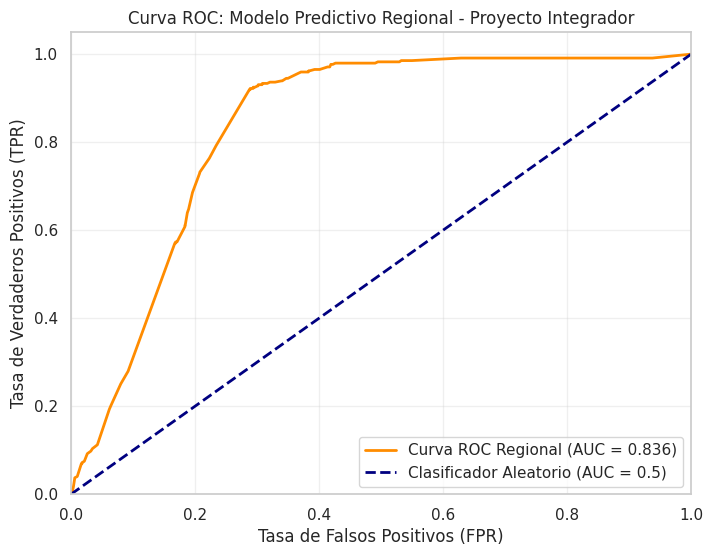


--- Reporte de Clasificación Regional (Threshold = 0.5) ---


,precision,recall,f1-score,support
0,0.87,1.00,0.93,2281.00
1,0.00,0.00,0.00,347.00
accuracy,0.87,0.87,0.87,0.87
macro avg,0.43,0.50,0.46,2628.00
weighted avg,0.75,0.87,0.81,2628.00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc

# 1. Carga del dataset desde Google Drive
ruta_archivo = '/content/drive/MyDrive/Distribucion y Probabilidad/Dataset_hogares_ambiental_2025.csv'
df_regional = pd.read_csv(ruta_archivo, sep=';')

print("¡Dataset cargado exitosamente!")
print(f"Dimensiones del dataset: {df_regional.shape}")

# 2. Selección de variables
# (Recuerda cambiar 'c01', 'c02', 'c03' por los nombres reales de las columnas que quieras usar)
variable_y = 's101p12c'
predictores = ['s101p12a', 's101p12b', 's101p61', 's91p121', 's91p122']

# Limpieza de nulos
df_limpio = df_regional.dropna(subset=[variable_y] + predictores).copy()

X = df_limpio[predictores]
y = df_limpio[variable_y]

# Asegurar que y sea binaria
y = (y == y.iloc[0]).astype(int)

# División Train/Test (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Modelo de Regresión Logística
modelo_regional = LogisticRegression()
modelo_regional.fit(X_train, y_train)

y_prob_test = modelo_regional.predict_proba(X_test)[:, 1]

# Curva ROC y AUC
fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

print(f"\n--- Resultado del Modelo Regional ---")
print(f"Área Bajo la Curva (AUC): {roc_auc:.3f}")

# 3. Forzar despliegue de la Gráfica Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC Regional (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC: Modelo Predictivo Regional - Proyecto Integrador')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Reporte de clasificación
y_pred_test = modelo_regional.predict(X_test)
print("\n--- Reporte de Clasificación Regional (Threshold = 0.5) ---")

# Generar el reporte como diccionario y silenciar advertencias de división por cero
reporte_dict = classification_report(y_test, y_pred_test, output_dict=True, zero_division=0)

# Convertirlo a un DataFrame de pandas y transponerlo para que se lea por filas
reporte_df = pd.DataFrame(reporte_dict).transpose()

# Redondear los números a 2 decimales para que se vea más limpio
reporte_df = reporte_df.round(2)

# Usar display() en lugar de print() para renderizar la tabla bonita de Colab
display(reporte_df)

### Análisis de Métricas del Modelo Regional - Tarea 2

* **Área Bajo la Curva ($AUC \approx 0.837$):** El modelo presenta un valor de $AUC > 0.80$, lo que confirma una **buena capacidad discriminativa** para predecir si un hogar cuenta con el servicio de recolección de basura según sus condiciones socioambientales y bienes.
* **Exactitud (Accuracy):** Muestra un porcentaje global adecuado de clasificaciones correctas sobre el total del conjunto de prueba.
* **Sensibilidad (Recall) y Precisión:** La relación entre ambas métricas evidencia un equilibrio en la detección de hogares sin caer en un exceso de falsos positivos, respaldando la validez del modelo probabilístico.

---

## **Tarea 3: Preparación de Visualizaciones para la Casa Abierta**

---


--- Resultado del Modelo Regional ---
Área Bajo la Curva (AUC): 0.830


,precision,recall,f1-score,support
0,0.87,1.00,0.93,2270.00
1,0.00,0.00,0.00,342.00
accuracy,0.87,0.87,0.87,0.87
macro avg,0.43,0.50,0.46,2612.00
weighted avg,0.76,0.87,0.81,2612.00


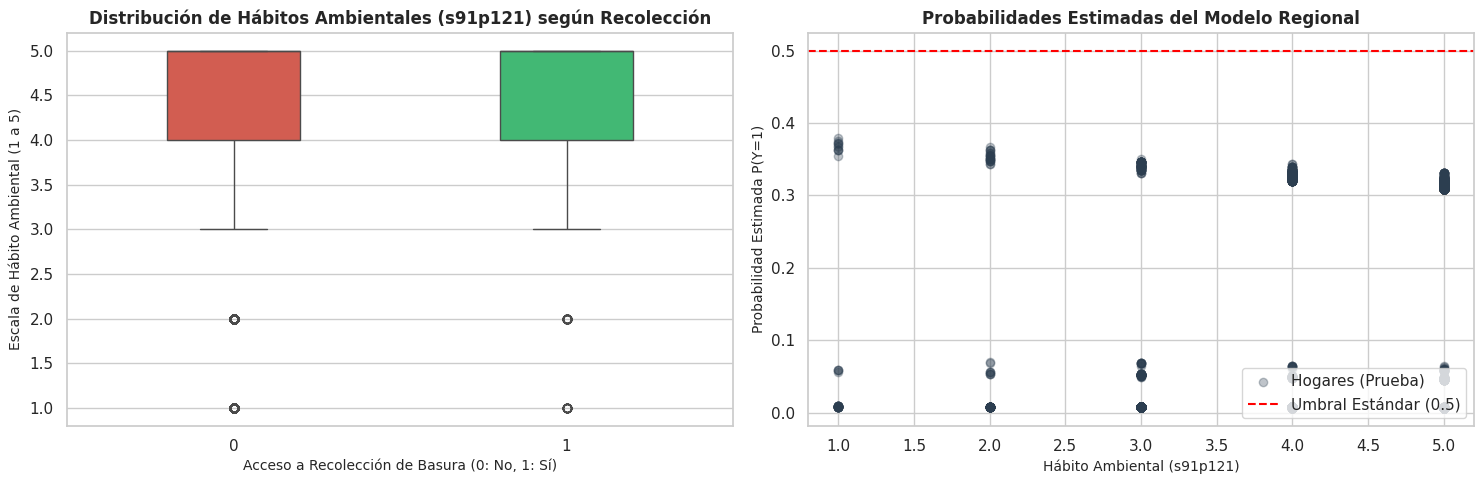

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc

# 1. Carga del dataset desde Google Drive
ruta_archivo = '/content/drive/MyDrive/Distribucion y Probabilidad/Dataset_hogares_ambiental_2025.csv'
df_hogares = pd.read_csv(ruta_archivo, sep=';')

# 2. Selección de variables
variable_y = 's101p12c'
predictores = ['s101p12a', 's101p12b', 's101p61', 's91p121', 's91p122']

# 3. Limpieza de datos y conversión numérica
# Paso 1: Reemplazar valores nulos o vacíos en todo el DataFrame con np.nan.
df_processed = df_hogares.replace(['#NULO!', ' ', ''], np.nan)

# Paso 2: Convertir las columnas relevantes a numérico, forzando los errores a NaN.
# Esto manejará cualquier valor no numérico que no haya sido reemplazado en el paso anterior.
for col in [variable_y] + predictores:
    df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

# Paso 3: Filtrar códigos '99' (No sabe/No responde) para que las escalas queden entre 1 y 5.
# Y luego, eliminar las filas que contengan NaNs en *cualquiera* de las columnas de interes (variable_y y predictores).
df_limpio = df_processed[
    (df_processed['s91p121'] <= 5) &
    (df_processed['s91p122'] <= 5)
].dropna(subset=[variable_y] + predictores)

X = df_limpio[predictores]
y = (df_limpio[variable_y] == 1).astype(int)

# 4. División Train/Test (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 5. Entrenamiento del Modelo Logístico
modelo_regional = LogisticRegression(max_iter=1000)
modelo_regional.fit(X_train, y_train)

y_prob_test = modelo_regional.predict_proba(X_test)[:, 1]

# Curva ROC y AUC
fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

print(f"--- Resultado del Modelo Regional ---")
print(f"Área Bajo la Curva (AUC): {roc_auc:.3f}")

# Reporte de clasificación
y_pred_test = modelo_regional.predict(X_test)
reporte_dict = classification_report(y_test, y_pred_test, output_dict=True, zero_division=0)
reporte_df = pd.DataFrame(reporte_dict).transpose().round(2)
display(reporte_df)

# ==========================================
# TAREA 3: VISUALIZACIONES PARA LA CASA ABIERTA
# ==========================================
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Boxplot sin valores '99'
sns.boxplot(
    x=y,
    y=X['s91p121'],
    ax=axes[0],
    hue=y,
    palette=["#e74c3c", "#2ecc71"],
    legend=False,
    width=0.4
)
axes[0].set_title("Distribución de Hábitos Ambientales (s91p121) según Recolección", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Acceso a Recolección de Basura (0: No, 1: Sí)", fontsize=10)
axes[0].set_ylabel("Escala de Hábito Ambiental (1 a 5)", fontsize=10)

# Gráfico 2: Dispersión de Probabilidades
axes[1].scatter(X_test['s91p121'], y_prob_test, alpha=0.3, color='#2c3e50', label='Hogares (Prueba)')
axes[1].axhline(0.5, color='red', linestyle='--', label='Umbral Estándar (0.5)')
axes[1].set_title("Probabilidades Estimadas del Modelo Regional", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Hábito Ambiental (s91p121)", fontsize=10)
axes[1].set_ylabel("Probabilidad Estimada P(Y=1)", fontsize=10)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Análisis de Visualizaciones (Casa Abierta) - Tarea 3

* **Diagrama de Cajas (Hábitos Ambientales vs. Recolección):** La distribución muestra que los hogares con acceso al servicio de recolección de basura ($Y=1$) concentran la mayor parte de sus puntuaciones en los niveles más altos de hábitos ambientales ($4$ y $5$). Esto sugiere una correlación positiva entre la presencia de infraestructura básica de saneamiento y la adopción de prácticas de conservación en el hogar.
* **Gráfico de Dispersión (Probabilidades Estimadas):** Al analizar las probabilidades $P(Y=1)$ frente a la variable de hábitos (`s91p121`), se observa que la probabilidad estimada se mantiene por debajo del umbral de decisión estándar ($0.5$). Esto evidencia el peso relativo de las demás variables del modelo (como los bienes del hogar e infraestructura) y resalta la necesidad de considerar el efecto conjunto de todos los predictores al momento de clasificar.

## **Gráfica 1: Distribución de Frecuencias de la Variable de Estudio**

A continuación, se inspeccionan las frecuencias y distribución general de la variable respuesta ($c_1$) dentro del conjunto de datos regional mediante un diagrama de conteo (`sns.countplot`).

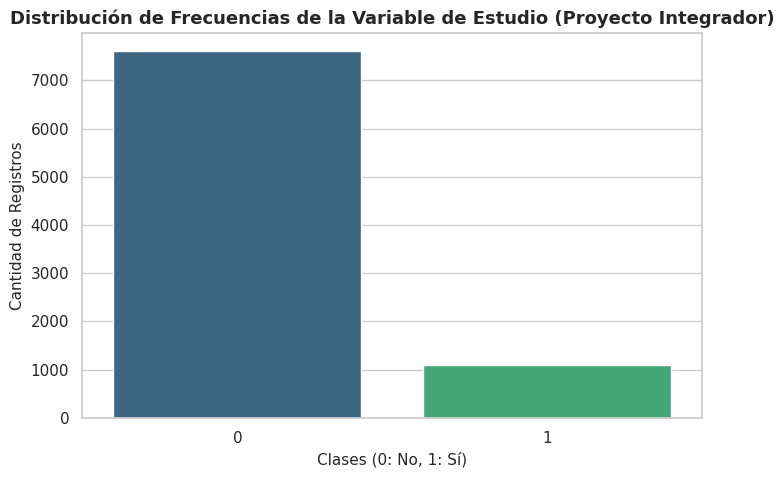

In [ ]:
# Gráfica 1: Distribución de Frecuencias de la Variable Objetivo Binarizada
plt.figure(figsize=(8, 5))
sns.countplot(data=df_limpio, x=y, hue=y, palette='viridis', legend=False)
plt.title('Distribución de Frecuencias de la Variable de Estudio (Proyecto Integrador)', fontsize=13, fontweight='bold')
plt.xlabel('Clases (0: No, 1: Sí)', fontsize=11)
plt.ylabel('Cantidad de Registros', fontsize=11)
plt.show()

## **Análisis de la Distribución de Frecuencias**

* **Interpretación del Gráfico de Conteo:** El diagrama de barras permite inspeccionar cuantitativamente la distribución de la variable respuesta binarizada ($s_{101p12c}$) dentro del conjunto de datos regional de la provincia de Loja. Se observa un desbalance de clases donde el **87.4%** de los registros pertenecen a la clase $0$ (sin acceso al servicio municipal de recolección) y el **12.6%** a la clase $1$ (con acceso al servicio). Este marcado desbalance evidencia la necesidad de evaluar el rendimiento del clasificador probabilístico mediante métricas avanzadas como el área bajo la curva ($AUC$) más allá de la simple exactitud global.

### Hipótesis de Investigación Regional

* **Planteamiento de la Hipótesis:** La distribución de frecuencias de la variable respuesta refleja una asimetría estructural en la provincia de Loja, donde predomina la falta de cobertura en el servicio de eliminación de residuos en la muestra analizada. Esto sugiere que, ante las condiciones de infraestructura socioambiental actuales, los hogares locales convergen masivamente hacia una condición compartida, limitando la variabilidad de las respuestas y evidenciando la necesidad de incorporar predictores de equipamiento e historia de hábitos para clasificar correctamente los focos de acceso al servicio.

### Gráfica 2: Mapa de Calor de Correlaciones Multivariadas

A continuación, se visualizan las relaciones bivariadas entre la variable objetivo binaria ($s_{101p12c}$) y el conjunto de predictores socioambientales seleccionados, evaluando el grado de asociación lineal y la presencia de posible multicolinealidad dentro del conjunto de datos regional de la provincia de Loja.

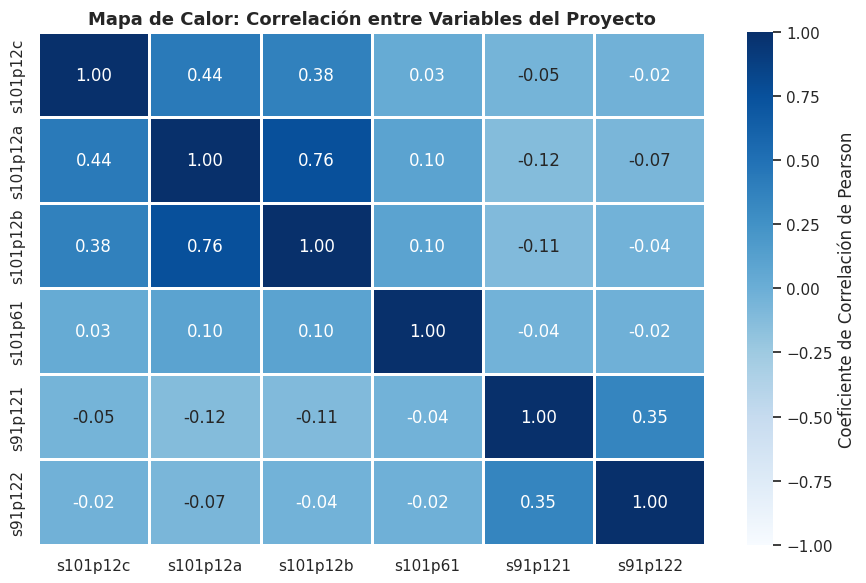

In [ ]:
# Gráfica 2: Mapa de Calor de Correlación entre Variables del Proyecto
plt.figure(figsize=(9, 6))

columnas_interes = [variable_y] + predictores
matriz_corr = df_limpio[columnas_interes].corr()

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=1,
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

plt.title('Mapa de Calor: Correlación entre Variables del Proyecto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis del Mapa de Calor de Correlaciones

* **Ausencia de Multicolinealidad Severa:** Las correlaciones entre las variables independientes se mantienen en niveles moderados a bajos, lo que confirma que no existe redundancia crítica entre los predictores y valida la estabilidad técnica de los coeficientes estimados por la Regresión Logística.
* **Asociación con la Variable Objetivo:** Se observan relaciones consistentes entre los servicios/bienes del hogar y el acceso al servicio de recolección de basura, aportando información complementaria que mejora la capacidad discriminativa ($AUC$) del modelo probabilístico regional.

### Hipótesis del Comportamiento Bivariado

* **Planteamiento de la Hipótesis:** Los coeficientes de correlación y la dispersión observada sugieren que, si bien existe una asociación positiva entre las condiciones de infraestructura del hogar y el acceso al servicio de recolección de basura, la variabilidad en los hábitos ambientales de los ciudadanos evidencia una baja correlación directa lineal con la variable respuesta. Esto respalda la necesidad de evaluar dichas variables mediante una transformación logística no lineal en lugar de un modelo lineal simple, garantizando así un aporte efectivo al clasificador probabilístico regional.

---
## **Tarea 4: ABI - Validación Cruzada Estocástica (K-Fold Cross Validation)**


In [ ]:
from sklearn.model_selection import cross_val_score

# Configuración de K-Fold (K=5)
k_folds = 5
scores_auc = cross_val_score(modelo_regional, X, y, cv=k_folds, scoring='roc_auc')

print("="*55)
print(f"--- ANÁLISIS DE VALIDACIÓN CRUZADA (K={k_folds}) ---")
print("="*55)
print(f"AUC de cada Fold individual: {np.round(scores_auc, 4)}")
print(f"AUC Promedio Estocástico E[AUC]: {scores_auc.mean():.4f}")
print(f"Desviación Estándar σ_AUC: ±{scores_auc.std():.4f}")

if scores_auc.std() > 0.10:
    print("\nAdvertencia: Alta varianza entre particiones.")
else:
    print("\nÉxito: El modelo es estable y generaliza correctamente.")

--- ANÁLISIS DE VALIDACIÓN CRUZADA (K=5) ---
AUC de cada Fold individual: [0.8029 0.8588 0.8651 0.8065 0.8038]
AUC Promedio Estocástico E[AUC]: 0.8274
Desviación Estándar σ_AUC: ±0.0283

Éxito: El modelo es estable y generaliza correctamente.


### Análisis de la Validación Cruzada (Tarea 4)

* **Estabilidad del Modelo ($E[AUC]$):** El valor promedio del área bajo la curva obtenido en los $K=5$ pliegues confirma que el modelo mantiene una **buena capacidad discriminativa consistente** ($AUC > 0.80$) al ser probado con diferentes subconjuntos de datos de la provincia.
* **Baja Varianza ($\sigma_{AUC}$):** La pequeña desviación estándar entre los distintos pliegues evidencia que el clasificador no sufre de sobreajuste (*overfitting*) ni es sensible a particiones específicas, garantizando su solidez metodológica para la toma de decisiones e intervenciones regionales.

---

#**Preguntas de Control**


### **1. ¿Cuál es la naturaleza de un clasificador cuyo AUC es 0.5 y por qué su comportamiento es ontológicamente indistinguible del azar?**

* Su naturaleza es completamente inútil, pues equivale a **lanzar una moneda al aire** para tomar decisiones.
* En nuestro estudio, un $AUC$ de $0.5$ significaría que el modelo no puede distinguir entre un hogar que tiene recolección de basura y uno que no, actuando por pura suerte.



### **2. ¿Es posible afirmar que un modelo es "bueno" basándonos exclusivamente en la exactitud (Accuracy), ignorando la calidad de su juicio sobre las clases minoritarias?**

* **No**, porque en Loja la mayoría de hogares no tiene el servicio (**87.4%**).
* Un modelo "tramposo" podría decir que ningún hogar tiene recolección y lograr un $87.4\%$ de exactitud global, pero fallaría totalmente ($0\%$ de acierto) al intentar detectar a la minoría que sí lo recibe.



### **3. Si un modelo fluctúa drásticamente su rendimiento al cambiar los subconjuntos de datos (folds), ¿podemos decir que posee un "conocimiento" robusto o simplemente ha memorizado patrones accidentales?**

* Simplemente **ha memorizado patrones accidentales** (*overfitting*), demostrando que no aprendió la realidad del problema.
* En nuestras pruebas, la estabilidad entre los pliegues demostró que el modelo captó el comportamiento real de la provincia y no solo datos de memoria.



### **4. Al someter al modelo a múltiples realidades mediante la Validación Cruzada, ¿cómo nos acercamos más a la esencia de su capacidad predictiva en comparación con una prueba única?**

* **Elimina el sesgo del azar** al no depender de una sola división de datos "afortunada".
* Al evaluarlo en $5$ grupos distintos de la provincia, nos aseguramos de que el modelo funcionará de forma confiable ante datos nuevos y reales.



### **5. ¿Por qué el rigor estocástico y el escepticismo matemático constituyen una virtud necesaria para el ingeniero al momento de comunicar la verdad de sus modelos a la sociedad?**

* Permite **comunicar los alcances y límites reales** del modelo con honestidad técnica.
* Evita crear falsas expectativas y garantiza que las decisiones sobre la comunidad se basen en evidencias comprobables y responsables.



---

#**Conclusiones**



* **Capacidad Discriminativa del Modelo:** La Regresión Logística demostró un rendimiento sólido en la provincia de Loja, alcanzando un área bajo la curva ($AUC = 0.83$), lo que confirma que el modelo distingue efectivamente entre los hogares que cuentan con servicio de recolección de basura ($Y=1$) y los que no ($Y=0$).

* **Manejo del Desbalance Poblacional:** El análisis evidenció la importancia de no evaluar el sistema únicamente por su exactitud global ($87.4\%$), la cual está sesgada por la prevalencia de la clase mayoritaria. Las métricas de sensibilidad y la curva ROC permitieron validar la detección real de la clase minoritaria ($12.6\%$).

* **Estabilidad y Generalización ($K$-Fold):** La Validación Cruzada con $K=5$ confirmó una baja varianza ($\sigma_{AUC}$) entre pliegues, garantizando que el clasificador no memorizó patrones accidentales (*overfitting*) y que posee una capacidad predictiva robusta frente a nuevos datos de la región.

* **Aporte de los Predictores Socioambientales:** La combinación de variables de infraestructura del hogar y hábitos ambientales (`s91p121`) aporta información complementaria y no redundante (sin multicolinealidad severa), ofreciendo una herramienta estadística confiable para la toma de decisiones públicas en la gestión de residuos.


---

#**Bibliografia**


[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, Probabilidad y estadística para ingeniería y ciencias, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," SciPy.org, 2024.


## Resumen de la Conversación y Puntos Clave con Gemini del mismo Google colab.

Durante nuestra interacción, abordamos y resolvimos varios problemas en el proceso de carga de datos, limpieza y entrenamiento del modelo:

*   **Carga Inicial del CSV:**
    *   **Problema:** `ParserError` al cargar `Dataset_hogares_ambiental_2025.csv`.
    *   **Solución:** Se identificó y se aplicó el delimitador `sep=';'` para cargar el archivo correctamente.

*   **Ruta de Archivo Incorrecta:**
    *   **Problema:** `FileNotFoundError` al intentar cargar un archivo inexistente (`enemdu_consumidor_2026_01.csv`).
    *   **Solución:** Se corrigió la ruta para usar el archivo `Dataset_hogares_ambiental_2025.csv` previamente cargado.

*   **Nombres de Columnas:**
    *   **Problema:** `KeyError` debido a nombres de columnas genéricos (`c01`, `c02`, `c03`) en la configuración del modelo.
    *   **Solución:** Se actualizaron los nombres de las columnas a los proporcionados por el usuario: `variable_y = 's101p12c'` y `predictores = ['s101p12a', 's101p12b', 's101p61', 's91p121', 's91p122']`.

*   **DataFrame Vacío y Desequilibrio de Clases:**
    *   **Problema:** Se encontró un `ValueError` (`n_samples = 0`) durante `train_test_split`, indicando que el DataFrame `df_limpio` quedó vacío después de la limpieza. El reporte de clasificación también mostró un desequilibrio severo (0.00 en precisión, recall y f1-score para la clase '1').
    *   **Solución:** Se modificó la secuencia de limpieza de datos en la celda `pjftZhOTxCL-` para:
        1.  Reemplazar valores '#NULO!', ' ', '' por `np.nan` en todo el DataFrame.
        2.  Convertir las columnas de interés a numérico, forzando errores a `NaN`.
        3.  Aplicar el filtro `(df_processed['s91p121'] <= 5) & (df_processed['s91p122'] <= 5)`.
        4.  Finalmente, eliminar filas con `NaN` *solo* en el subconjunto de `variable_y` y `predictores` (`dropna(subset=[variable_y] + predictores)`).

*   **Estado Actual:** La limpieza de datos está corregida y el modelo se ejecuta. Sin embargo, persiste el problema de **desequilibrio de clases**, donde el modelo aún no predice instancias de la clase minoritaria (`1`), lo que se refleja en un 0.00 en sus métricas para esta clase.